In [18]:
import pandas as pd
import numpy as np

In [19]:
# ✅ Day 1: Data + EDA (Python)

# Goal: Understand the data deeply

# Download dataset (Bank Customer Churn)
# Load using Pandas
# Clean data
# Do EDA (plots + insights)

In [ ]:
df = pd.read_csv('Data\Bank Customer Churn Prediction.csv')

In [21]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [23]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [24]:
print(df.isnull().sum())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [25]:
print(df.duplicated().sum())

0


In [26]:
#churn distribution
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [27]:
#churn distribution percentage
a = df['churn'].value_counts(normalize=True)
a*100

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

In [28]:
#avg balance
df['balance'].mean()

76485.889288

In [29]:
#group by geography - for each country what percentage of customers have left the bank
df.groupby('country')['churn'].mean()

country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64

In [30]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

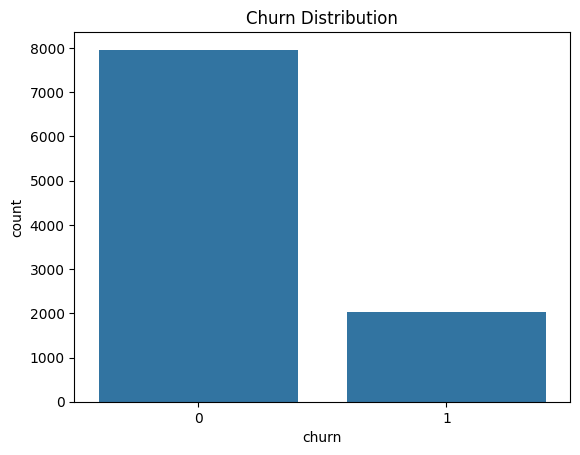

In [32]:
#churn count
sns.countplot(x = 'churn', data = df)
plt.title('Churn Distribution')
plt.show()

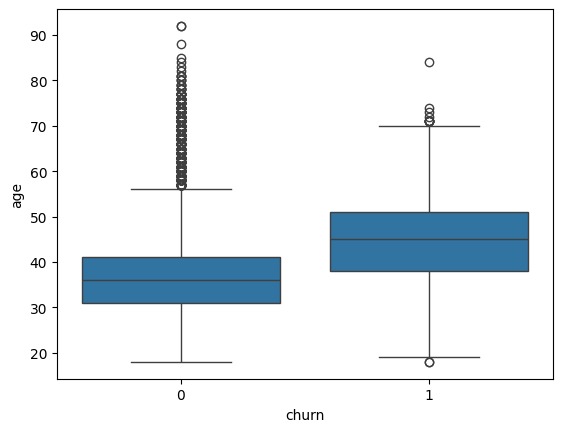

In [33]:
#age vs churn
sns.boxplot(x = 'churn', y = 'age', data = df)
plt.show()

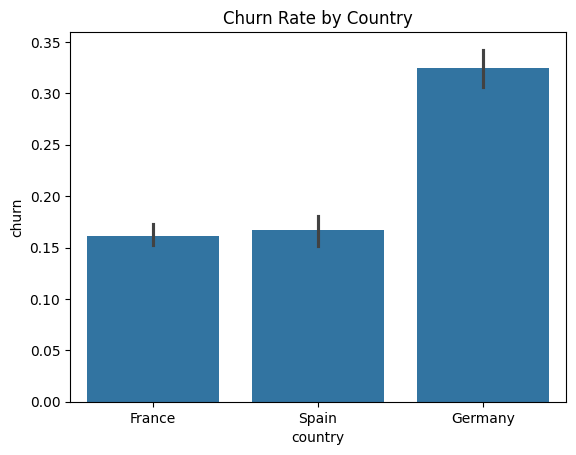

In [34]:
#country vs churn
sns.barplot(x = 'country', y = 'churn', data = df)
plt.title('Churn Rate by Country')
plt.show()

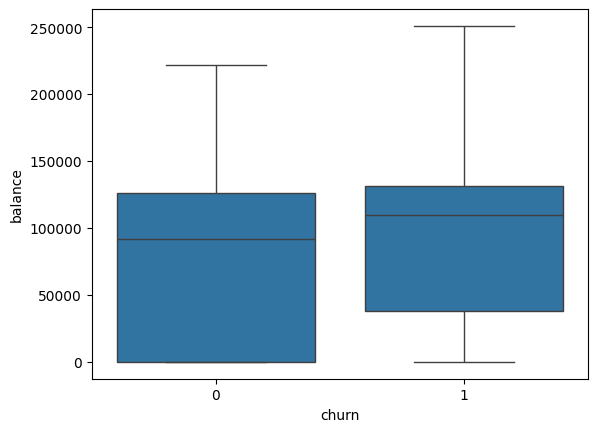

In [35]:
#balance vs churn
sns.boxplot(x = 'churn', y = 'balance', data = df)
plt.show()

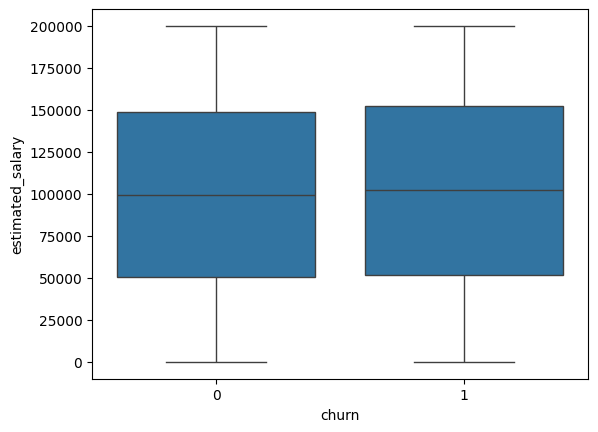

In [36]:
sns.boxplot(x='churn', y='estimated_salary', data=df)
plt.show()

In [37]:
#Analysis:
#1.Majority of customers are non-churn (0), but a significant portion has churned.
#2.Customers aged 37+ have higher churn rate
#3.Germany region shows higher churn while Spain and France have lesser churn rate

#4.Customers who churned tend to have a slightly higher average account balance.
#However, further analysis is needed to confirm whether balance strongly influences churn.

#5.Estimated salary does not show a significant difference between customers who churned and those who did not.
#This suggests that salary is not a strong factor influencing customer churn.

In [38]:
# 1. The dataset shows that most customers have not churned; however, a considerable proportion of customers have left the bank, indicating a meaningful churn problem.

# 2. Customers aged 37 and above exhibit a higher tendency to churn, suggesting age may influence customer retention.

# 3. Churn rates vary by geography, with Germany showing the highest churn rate compared to France and Spain, indicating potential regional factors affecting customer behavior.

# 4. Customers who churned tend to have a slightly higher average account balance. This may indicate that high-value customers are more likely to switch banks, possibly in search of better services or benefits.

# 5. Estimated salary does not show a significant difference between churned and non-churned customers, suggesting that income level is not a primary driver of customer churn.

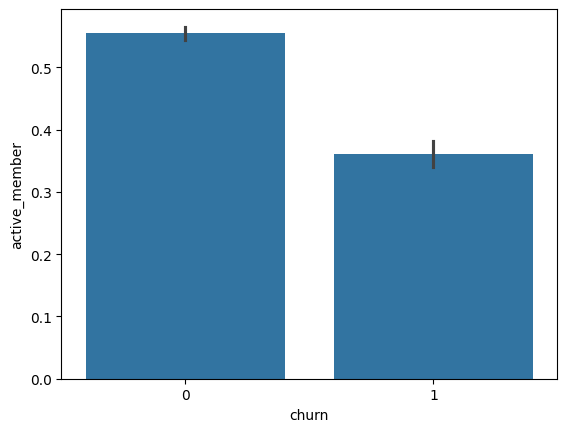

In [39]:
#churn vs active member
sns.barplot(x = 'churn', y = 'active_member', data = df)
plt.show()


In [40]:
#EDA

# 1. The dataset shows that most customers have not churned; however, a considerable proportion of customers have left the bank, indicating a meaningful churn problem.

# 2. Customers aged 37 and above exhibit a higher tendency to churn, suggesting age may influence customer retention.

# 3. Churn rates vary by geography, with Germany showing the highest churn rate compared to France and Spain, indicating potential regional factors affecting customer behavior.

# 4. Customers who churned tend to have a slightly higher average account balance. This may indicate that high-value customers are more likely to switch banks, possibly in search of better services or benefits.

# 5. Estimated salary does not show a significant difference between churned and non-churned customers, suggesting that income level is not a primary driver of customer churn.

#6 . Active members are significantly less likely to churn compared to inactive customers.
#This suggests that customer engagement plays a crucial role in retention.
# Customers who are actively engaged with the bank’s services are more likely to stay,
#while inactive users have a higher probability of churn.

In [41]:
# ✅ Day 2: SQL + Feature Engineering

# Goal: Show analytical thinking

# Create SQL queries
# Extract insights
# Create new features

In [42]:
import sqlite3

In [43]:
conn = sqlite3.connect('bank.db')
df.to_sql('customers', conn, if_exists='replace', index = False)

10000

In [44]:
#verify
pd.read_sql("SELECT COUNT(*) FROM customers", conn)

,COUNT(*)
0,10000


In [45]:
#churn rate by country
query = """
SELECT country, AVG(churn) as churn_rate
FROM customers
GROUP BY country
"""
pd.read_sql(query, conn)

,country,churn_rate
0,France,0.161548
1,Germany,0.324432
2,Spain,0.166734


In [46]:
query = """
SELECT country, ROUND(AVG(churn)*100, 2) as churn_rate
FROM customers
GROUP BY country
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)

,country,churn_rate
0,Germany,32.44
1,Spain,16.67
2,France,16.15


In [47]:
#avg balance by churn
query = """
SELECT churn, AVG(balance) as avg_balance
FROM customers
GROUP BY churn
"""
pd.read_sql(query, conn)

,churn,avg_balance
0,0,72745.296779
1,1,91108.539337


In [48]:
# High-risk customer segment
query = """
SELECT
  CASE
    WHEN age < 30 THEN 'Young'
    WHEN age BETWEEN 30 AND 50 THEN 'Middle'
    ELSE 'Senior'
  END AS age_group,
  ROUND(AVG(churn)*100, 2) as churn_rate
FROM customers
GROUP BY age_group
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)

,age_group,churn_rate
0,Senior,44.65
1,Middle,19.02
2,Young,7.56


In [49]:
#Conclusion
"""
Senior customers exhibit the highest churn rate (44.65%), significantly higher than middle-aged and younger customers, indicating that age is a strong factor influencing customer attrition.
"""
#Reasoning
"""
The high churn rate among senior customers may be due to lower engagement with digital platforms or dissatisfaction with services, highlighting the need for more accessible and customer-friendly solutions.
"""
#Solution
"""
The bank should focus on retaining senior customers by improving their overall banking experience.
This could include offering personalized services, simplified digital interfaces, dedicated customer support, and tailored financial products that suit their needs.
"""


'\nThe bank should focus on retaining senior customers by improving their overall banking experience.\nThis could include offering personalized services, simplified digital interfaces, dedicated customer support, and tailored financial products that suit their needs.\n'

In [50]:
# Active vs inactive
query = """
SELECT active_member,
ROUND(AVG(churn)*100, 2) as churn_rate
FROM customers
GROUP BY active_member
"""
pd.read_sql(query, conn)

,active_member,churn_rate
0,0,26.85
1,1,14.27


In [51]:
#Conclusion
"""
Inactive customers show a significantly higher churn rate (26.85%) compared to active customers (14.27%).
This indicates that customer engagement plays a critical role in retention, and inactive users are at a much higher risk of leaving the bank.
"""
#Solution
"""
Improving customer engagement could be an effective strategy to reduce churn, as active users are significantly more likely to stay with the bank.
"""

'\nImproving customer engagement could be an effective strategy to reduce churn, as active users are significantly more likely to stay with the bank.\n'

In [52]:
#Balance segmentation
query = """
SELECT
  CASE
    WHEN balance = 0 THEN 'Zero balance'
    WHEN balance BETWEEN 1 AND 50000 THEN 'Low balance'
    ELSE 'Hight balance'
  END AS balance_group,
  ROUND(AVG(churn)*100, 2) as churn_rate
FROM customers
GROUP BY balance_group
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)


,balance_group,churn_rate
0,Low balance,34.67
1,Hight balance,23.95
2,Zero balance,13.82


In [53]:
#Conclusion
"""
Customers with low account balance exhibit the highest churn rate (34.67%) compared to high balance and zero balance customers, indicating that account balance is a significant factor influencing customer retention.
Zero balance customers show the lowest churn rate, possibly indicating that such accounts are maintained with minimal effort and do not actively drive switching behavior.
"""
#Reason
"""
Low balance customers may have weaker engagement or lower dependency on the bank’s services, making them more likely to switch to competitors.
"""
#Solution
"""
The bank should focus on retaining low balance customers by increasing engagement through personalized offers, incentives, and value-added services to improve customer loyalty.
"""

'\nThe bank should focus on retaining low balance customers by increasing engagement through personalized offers, incentives, and value-added services to improve customer loyalty.\n'

In [54]:
#Credit score segmentation
query = """
SELECT
  CASE
    WHEN credit_score < 500 THEN 'Low'
    WHEN credit_score BETWEEN 500 AND 700 THEN 'Medium'
    ELSE 'High'
  END AS credit_score_group,
  ROUND(AVG(churn)*100, 2) as churn_rate
FROM customers
GROUP BY credit_score_group
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)


,credit_score_group,churn_rate
0,Low,23.73
1,Medium,20.28
2,High,19.87


In [55]:
#Final Conclusion
"""
Customers with low credit scores exhibit a slightly higher churn rate (23.73%) compared to medium and high credit groups.
However, the difference is minimal, suggesting that credit score is not a primary factor driving customer churn.

While providing financial guidance may improve customer satisfaction, the bank should focus more on engagement and service-related factors to effectively reduce churn.
"""

'\nCustomers with low credit scores exhibit a slightly higher churn rate (23.73%) compared to medium and high credit groups.\nHowever, the difference is minimal, suggesting that credit score is not a primary factor driving customer churn.\n\nWhile providing financial guidance may improve customer satisfaction, the bank should focus more on engagement and service-related factors to effectively reduce churn.\n'

In [56]:
#Combined insight
query = """
SELECT
  country,
  active_member,
  ROUND(AVG(churn)*100, 2) as churn_rate
  FROM customers
  GROUP BY country, active_member
  ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)

,country,active_member,churn_rate
0,Germany,0,41.08
1,Germany,1,23.72
2,Spain,0,23.35
3,France,0,21.13
4,France,1,11.50
5,Spain,1,10.75


In [57]:
#Conclusion
"""
Inactive customers consistently exhibit higher churn rates across all regions, indicating that customer engagement is a key factor influencing retention irrespective of geography.
"""
#Reason
"""
This pattern suggests that lack of engagement or reduced interaction with banking services may increase the likelihood of customers leaving.
"""
#Solution
"""
The bank should proactively target inactive customers by identifying the reasons for reduced engagement through feedback and behavioral analysis.
Based on these insights, the bank can implement personalized communication, improve service quality, and introduce engagement strategies to retain customers.
"""

'\nThe bank should proactively target inactive customers by identifying the reasons for reduced engagement through feedback and behavioral analysis.\nBased on these insights, the bank can implement personalized communication, improve service quality, and introduce engagement strategies to retain customers.\n'

In [58]:
#Adding groups
df['age_group'] = pd.cut(df['age'], bins=[18,30,50,100], labels=['Young','Middle','Senior'])
df['balance_group'] = df['balance'].apply(lambda x : "High" if x >=50000 else "Low")
df['credit_score_group'] = pd.cut(df['credit_score'], bins = [300,500,700,900], labels = ['Low','Medium','High'])


In [59]:
print(df.groupby('age_group')['churn'].mean())
print(df.groupby('balance_group')['churn'].mean())
print(df.groupby('credit_score_group')['churn'].mean())

age_group
Young     0.075026
Middle    0.195835
Senior    0.446471
Name: churn, dtype: float64
balance_group
High    0.239537
Low     0.142470
Name: churn, dtype: float64
credit_score_group
Low       0.236392
Medium    0.202852
High      0.198652
Name: churn, dtype: float64


C:\Users\pragy\AppData\Local\Temp\ipykernel_2080\507178186.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('age_group')['churn'].mean())
C:\Users\pragy\AppData\Local\Temp\ipykernel_2080\507178186.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('credit_score_group')['churn'].mean())


In [60]:
df.to_csv("clean-bank-customer-churn-prediction.csv", index = False)

In [61]:
df.head(1)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_group,balance_group,credit_score_group
0,15634602,619,France,Female,42,2,0.0,1,1,1,101348.88,1,Middle,Low,Medium


In [62]:
"""
✅ Day 3: Dashboard (Power BI / Tableau)

Goal: Visual storytelling

Import data
Create:
Churn distribution
Customer segments
Revenue insights
"""

'\n✅ Day 3: Dashboard (Power BI / Tableau)\n\nGoal: Visual storytelling\n\nImport data\nCreate:\nChurn distribution\nCustomer segments\nRevenue insights\n'

In [63]:
"""
💻 DAY 3 — Dashboard

Use Power BI:

Create:

KPI cards (Total Customers, Churn Rate)
Pie chart (Churn vs Non-churn)
Bar chart (Country vs churn)
Line chart (Age trends)

🎯 Goal

Turn your analysis into visual + business story
"""

'\n💻 DAY 3 — Dashboard\n\nUse Power BI:\n\nCreate:\n\nKPI cards (Total Customers, Churn Rate)\nPie chart (Churn vs Non-churn)\nBar chart (Country vs churn)\nLine chart (Age trends)\n\n🎯 Goal\n\nTurn your analysis into visual + business story\n'